### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('data/drugLibTrain_raw.tsv', sep='\t')

# lee el archivo .tsv en un dataframe

In [3]:
df

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above
...,...,...,...,...,...,...,...,...,...
3102,1039,vyvanse,10,Highly Effective,Mild Side Effects,adhd,"Increased focus, attention, productivity. Bett...","Restless legs at night, insomnia, headache (so...","I took adderall once as a child, and it made m..."
3103,3281,zoloft,1,Ineffective,Extremely Severe Side Effects,depression,Emotions were somewhat blunted. Less moodiness.,"Weight gain, extreme tiredness during the day,...",I was on Zoloft for about 2 years total. I am ...
3104,1664,climara,2,Marginally Effective,Moderate Side Effects,total hysterctomy,---,Constant issues with the patch not staying on....,---
3105,2621,trileptal,8,Considerably Effective,Mild Side Effects,epilepsy,Controlled complex partial seizures.,"Dizziness, fatigue, nausea",Started at 2 doses of 300 mg a day and worked ...


### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categoricas con pocas categorias (10 como mucho)

In [4]:
print(df.info())
print(df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         3107 non-null   int64
 1   urlDrugName        3107 non-null   str  
 2   rating             3107 non-null   int64
 3   effectiveness      3107 non-null   str  
 4   sideEffects        3107 non-null   str  
 5   condition          3106 non-null   str  
 6   benefitsReview     3089 non-null   str  
 7   sideEffectsReview  3032 non-null   str  
 8   commentsReview     3095 non-null   str  
dtypes: int64(2), str(7)
memory usage: 218.6 KB
None
Unnamed: 0           3107
urlDrugName           502
rating                 10
effectiveness           5
sideEffects             5
condition            1426
benefitsReview       3031
sideEffectsReview    2813
commentsReview       3046
dtype: int64


In [8]:
# selecciona solo las columnas que cumplan ese criterio
df = df[['rating', 'effectiveness', 'sideEffects']].copy()
df.head()

,rating,effectiveness,sideEffects
0,4,Highly Effective,Mild Side Effects
1,1,Highly Effective,Severe Side Effects
2,10,Highly Effective,No Side Effects
3,3,Marginally Effective,Mild Side Effects
4,2,Marginally Effective,Severe Side Effects


<function matplotlib.pyplot.show(close=None, block=None)>

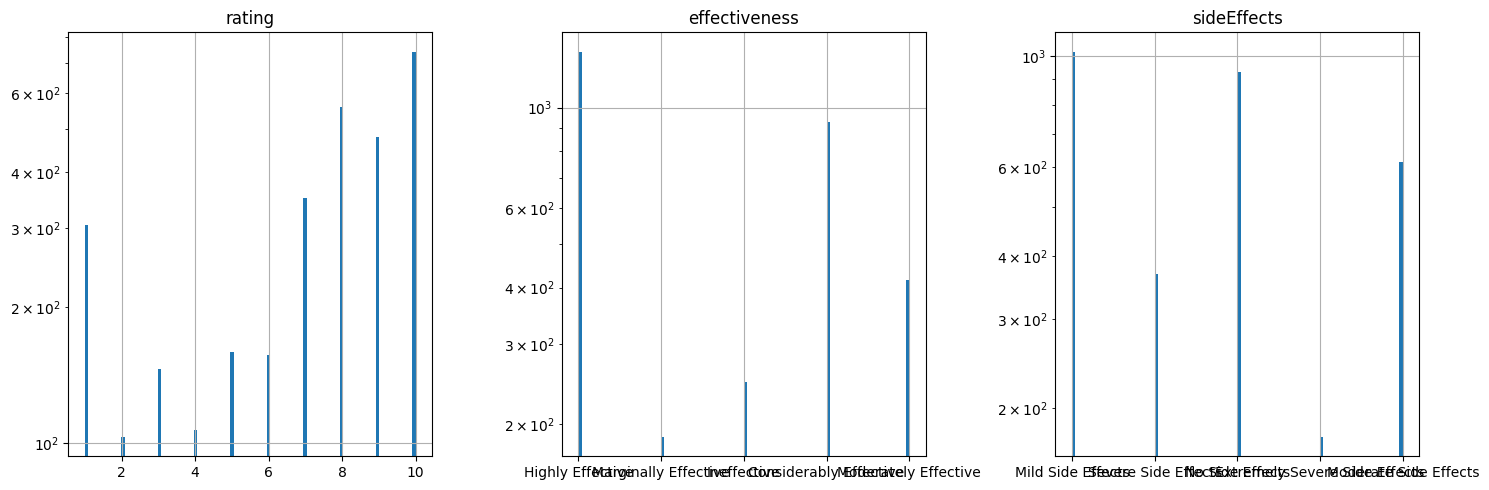

In [9]:
# diagramas de barras para las frecuencias acumuladas de las categorías

import matplotlib.pyplot as plt

figure = plt.figure(figsize=(15,5))

for n, c in enumerate(df.columns):
  ax = figure.add_subplot(1,3,n+1)
  ax.set_title(c)
  ax.set_yscale("log") #the log scale help us to have a better idea of our data when the distribution is not fair
  df[c].hist(ax=ax, bins=100)

figure.tight_layout() #this feature separate the graphs correctly
plt.show

#### Transforma las columnas categoricas

Transforma las columnas categóricas no codificadas a numéricas mediante dummies.

In [10]:
# ojo, las columnas categóricas no codificadas ya
df_dummies = pd.get_dummies(df, columns=['effectiveness', 'sideEffects'], drop_first=False)
df_dummies = df_dummies.astype(float)
df_dummies.head()

,rating,effectiveness_Considerably Effective,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Extremely Severe Side Effects,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects
0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,10.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


#### Evalúa cuál es la mejor K

Utiliza silhouette_score para evaluar cuál es la mejor K. Evalúa como mucho K = 20

#### Genera el K Means 

In [12]:
inercias = []
siluetas = []
ks = range(2, 21)

# usa el KMeans y el score de silueta
# ajusta el kmeans con k entre 1 y 20

In [14]:
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_dummies)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(df_dummies, labels))
    print(f'K={k:2d} | inercia={km.inertia_:.2f} | silhouette={siluetas[-1]:.4f}')

# calcula los scores de silueta para cada modelo

K= 2 | inercia=9743.17 | silhouette=0.6055
K= 3 | inercia=6257.99 | silhouette=0.4382
K= 4 | inercia=4828.18 | silhouette=0.3971
K= 5 | inercia=4303.96 | silhouette=0.3884
K= 6 | inercia=3831.11 | silhouette=0.3674
K= 7 | inercia=3462.26 | silhouette=0.3772
K= 8 | inercia=3227.60 | silhouette=0.3978
K= 9 | inercia=2992.48 | silhouette=0.4059
K=10 | inercia=2851.95 | silhouette=0.4192
K=11 | inercia=2626.97 | silhouette=0.4201
K=12 | inercia=2523.67 | silhouette=0.4586
K=13 | inercia=2389.09 | silhouette=0.4894
K=14 | inercia=2301.56 | silhouette=0.4622
K=15 | inercia=2210.95 | silhouette=0.5139
K=16 | inercia=2136.64 | silhouette=0.4804
K=17 | inercia=1980.20 | silhouette=0.5145
K=18 | inercia=1979.83 | silhouette=0.5246
K=19 | inercia=1899.63 | silhouette=0.5356
K=20 | inercia=1817.68 | silhouette=0.5409


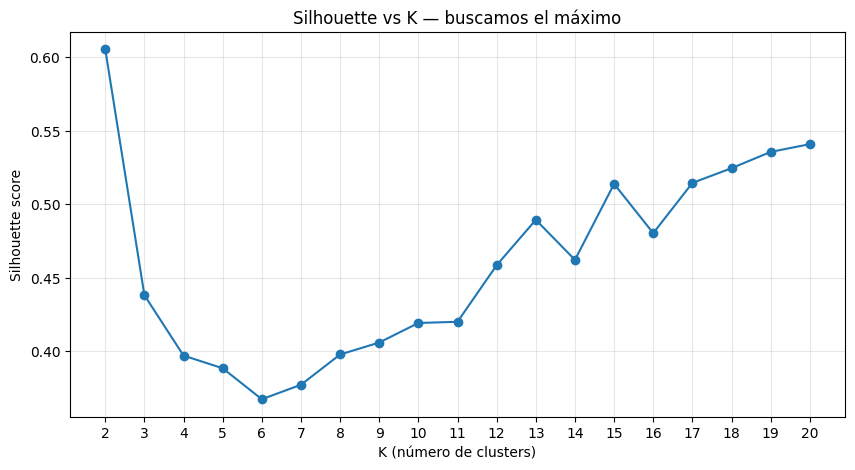

In [15]:
# pinta los scores de silueta para cada k
plt.figure(figsize=(10, 5))
plt.plot(list(ks), siluetas, marker='o')
plt.xlabel('K (número de clusters)')
plt.ylabel('Silhouette score')
plt.title('Silhouette vs K — buscamos el máximo')
plt.xticks(list(ks))
plt.grid(True, alpha=0.3)
plt.show()

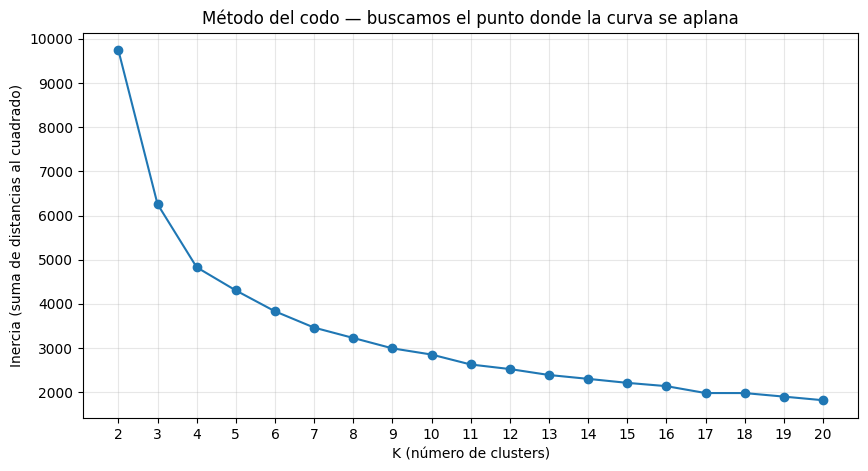

In [17]:
# pinta las inercias para cada k
plt.figure(figsize=(10, 5))
plt.plot(list(ks), inercias, marker='o')
plt.xlabel('K (número de clusters)')
plt.ylabel('Inercia (suma de distancias al cuadrado)')
plt.title('Método del codo — buscamos el punto donde la curva se aplana')
plt.xticks(list(ks))
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# entrena un kmeans con el valor de k óptimo seleccionado
k_optima = list(ks)[int(np.argmax(siluetas))]
print(f'K óptima según silhouette: {k_optima}')

kmeans_final = KMeans(n_clusters=k_optima, random_state=42, n_init=10)
etiquetas = kmeans_final.fit_predict(df_dummies)

df_dummies['cluster'] = etiquetas
df_dummies.head()

K óptima según silhouette: 2


,rating,effectiveness_Considerably Effective,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Extremely Severe Side Effects,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects,cluster
0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
2,10.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1
4,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1


#### Muestra en un gráfico de quesito la distribución de los distintos clusters

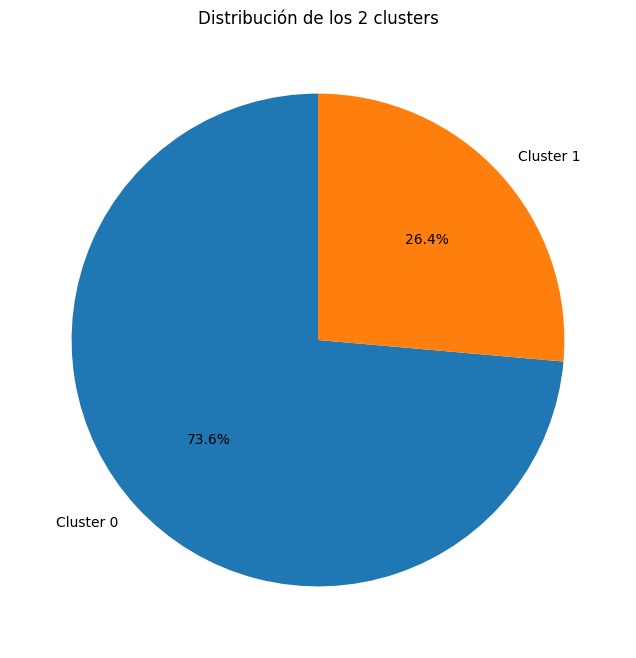

Tamaños de cada cluster:
0    2287
1     820
Name: count, dtype: int64


In [19]:
conteos = pd.Series(etiquetas).value_counts().sort_index()

plt.figure(figsize=(8, 8))
plt.pie(conteos.values,
        labels=[f'Cluster {i}' for i in conteos.index],
        autopct='%1.1f%%',
        startangle=90)
plt.title(f'Distribución de los {k_optima} clusters')
plt.show()

print('Tamaños de cada cluster:')
print(conteos)

# a partir del kmeans calculado, muestra la proporción de clusters en un diagrama de quesito
